# 📊 Analiza i Raport – Osoba 5
**Projekt: Vision Transformer vs CNN | GRUPA 3**

## Zadanie na następną lekcję
Analiza porównawcza wyników CNN vs ViT na CIFAR-10:
- [ ] Wczytać wyniki z `wyniki_eksperymentow.json` (Dalkowski)
- [ ] Wykres: **krzywe uczenia** (train/test accuracy per epoch) dla CNN i ViT
- [ ] Wykres: **porównanie test accuracy** przy różnych patch_size
- [ ] Wykres: **czas treningu vs accuracy** (scatter plot)
- [ ] Tabela: **liczba parametrów** CNN vs ViT
- [ ] Opis: **lokalne (CNN) vs globalne (Attention)** przetwarzanie obrazu
- [ ] Wnioski końcowe (kiedy ViT lepszy, kiedy CNN lepszy)

In [10]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

## 1. Wczytanie wyników eksperymentów

In [ ]:

# with open(f'{PROJECT_PATH}/wyniki_eksperymentow.json') as f:
#     data = json.load(f)

# df_epochs    = pd.DataFrame(data['exp1_epochs'])
# df_patchsize = pd.DataFrame(data['exp2_patchsize'])
# df_layers    = pd.DataFrame(data['exp3_layers'])
# df_heads     = pd.DataFrame(data['exp4_heads'])
# df_cnn_cfg   = pd.DataFrame(data['exp5_cnn_config'])

#  dane zastępcze 
dummy_history_cnn = [{'epoch': e, 'train_acc': 50 + e*4, 'test_acc': 48 + e*2.5} for e in range(1, 11)]
dummy_history_vit = [{'epoch': e, 'train_acc': 40 + e*4.5, 'test_acc': 38 + e*3} for e in range(1, 11)]
print("Dane wczytane (zastępcze)") 

Dane wczytane (zastępcze – zamień na prawdziwe!)


## 2. Krzywe uczenia – CNN vs ViT

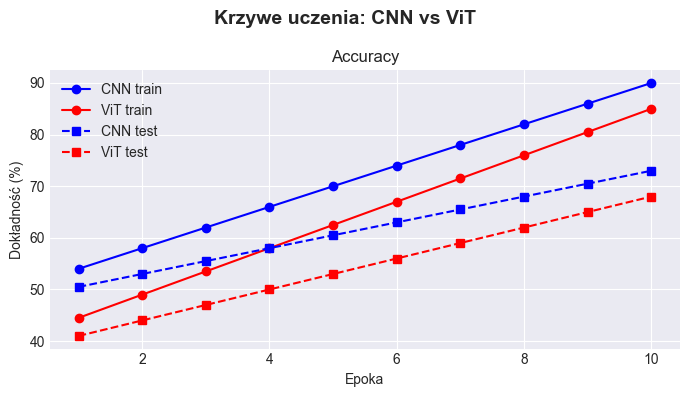

In [18]:
import matplotlib.pyplot as plt

def plot_learning_curves(history_cnn, history_vit, title='Krzywe uczenia: CNN vs ViT'):
    # Zmiana: dodano fig, aby poprawnie rozpakować subplots
    fig, ax = plt.subplots(figsize=(7, 4))
    
    epochs_cnn = [h['epoch'] for h in history_cnn]
    epochs_vit = [h['epoch'] for h in history_vit]
    
    # Train accuracy - zmiana z axes na ax
    ax.plot(epochs_cnn, [h['train_acc'] for h in history_cnn], 'b-o', label='CNN train')
    ax.plot(epochs_vit, [h['train_acc'] for h in history_vit], 'r-o', label='ViT train')
    ax.plot(epochs_cnn, [h['test_acc']  for h in history_cnn], 'b--s', label='CNN test')
    ax.plot(epochs_vit, [h['test_acc']  for h in history_vit], 'r--s', label='ViT test')
    
    ax.set_xlabel('Epoka')
    ax.set_ylabel('Dokładność (%)')
    ax.set_title('Accuracy')
    ax.legend()
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout() # Opcjonalne: poprawia odstępy
    plt.show()

plot_learning_curves(dummy_history_cnn, dummy_history_vit)

## 3. Wpływ patch_size na accuracy (ViT)

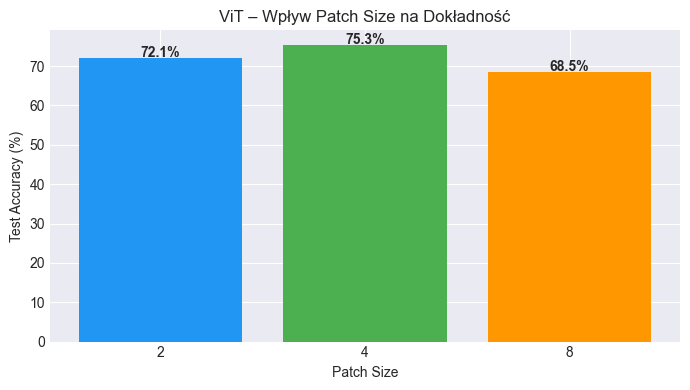

In [ ]:
# tu są wymyślone dane
dummy_patch = pd.DataFrame({
    'patch_size':  [2, 4, 8],
    'num_patches': [256, 64, 16],
    'test_acc':    [72.1, 75.3, 68.5],
    'train_time_s':[800, 500, 300],
})

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dummy_patch['patch_size'].astype(str), dummy_patch['test_acc'],
       color=['#2196F3', '#4CAF50', '#FF9800'])
ax.set_xlabel('Patch Size')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('ViT – Wpływ Patch Size na Dokładność')
for i, v in enumerate(dummy_patch['test_acc']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Tabela porównawcza CNN vs ViT

In [ ]:
comparison = pd.DataFrame([
    {'Model': 'CNN (baseline)',   'Test Acc (%)': 75.5, 'Parametry': '???', 'Czas treningu (s)': 1181, 'BatchNorm': 'Nie', 'Dropout': 'Nie'},
    {'Model': 'CNN +BN+DO',       'Test Acc (%)': '???', 'Parametry': '???', 'Czas treningu (s)': '???', 'BatchNorm': 'Tak', 'Dropout': 'Tak'},
    {'Model': 'ViT (patch=4)',    'Test Acc (%)': '???', 'Parametry': '???', 'Czas treningu (s)': '???', 'BatchNorm': '-',   'Dropout': '-'},
    {'Model': 'ViT (patch=2)',    'Test Acc (%)': '???', 'Parametry': '???', 'Czas treningu (s)': '???', 'BatchNorm': '-',   'Dropout': '-'},
    {'Model': 'ViT (patch=8)',    'Test Acc (%)': '???', 'Parametry': '???', 'Czas treningu (s)': '???', 'BatchNorm': '-',   'Dropout': '-'},
])

print(comparison.to_string(index=False))

         Model Test Acc (%) Parametry Czas treningu (s) BatchNorm Dropout
CNN (baseline)         75.5       ???              1181       Nie     Nie
    CNN +BN+DO          ???       ???               ???       Tak     Tak
 ViT (patch=4)          ???       ???               ???         -       -
 ViT (patch=2)          ???       ???               ???         -       -
 ViT (patch=8)          ???       ???               ???         -       -


## 5. Wnioski – CNN vs ViT (lokalnie vs globalnie)



### CNN – przetwarzanie lokalne
- Filtry konwolucyjne wykrywają lokalne cechy (krawędzie, tekstury)
- Hierarchia cech: niskie warstwy = proste cechy, wysokie = abstrakcyjne

### ViT – przetwarzanie globalne (Attention)
- Każdy patch "widzi" wszystkie inne patche (self-attention)

### Wnioski 
1. Który model osiągnął lepszą dokładność? 
2. Który trenuje się szybciej? 
3. Jak patch_size wpływa na wyniki ViT? 
4. Czy BatchNorm/Dropout poprawia CNN? 